# Problématique 

## Objectif
L'objectif de ce projet est de mettre en place une démarche d'A/B testing rigoureuse afin de comparer deux variantes d'une expérience digitale, mesurer leur impact réel sur le comportement utilisateur et prendre une décision marketing ou produit basée sur les données.

- **Dataset utilisé** : [Website A/B Testing Dataset - Kaggle](https://www.kaggle.com/datasets/zeusdatasets/website-ab-testing-dataset)

## KPI à atteindre
- Augmentation du taux de conversion sur la variante testée
- Différence statistiquement significative avec un niveau de confiance de 95 % minimum
- Puissance statistique suffisante pour limiter le risque d'erreur
- Impact positif sur le KPI principal sans dégradation des KPI secondaires
- Taille d'échantillon suffisamment grande pour valider les résultats de façon fiable

## QUESTIONS BUSINESS
- La variante testée améliore-t-elle réellement la conversion par rapport au groupe contrôle ?
- Quel est l'impact de la variation sur les revenus, les clics ou l'engagement ?
- Le gain observé est-il statistiquement significatif ou simplement dû au hasard ?
- Quels segments d'utilisateurs réagissent le mieux à la nouvelle version ?
- Faut-il déployer la variante à l'ensemble des utilisateurs ou poursuivre les tests ?

## Livrables attendus
- Notebook propre avec préparation des données, analyse et interprétation
- Définition claire des groupes contrôle et test
- Analyse exploratoire des métriques principales et secondaires
- Vérification des hypothèses statistiques
- Calcul du taux de conversion et de l'uplift
- Test statistique adapté à la problématique
- Estimation de la significativité et de l'intervalle de confiance

# Analyse Exploratoire des Données

#### Import des bibliothèques 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

#### Compréhension de nos données 

In [ ]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


(294478, 5)

In [ ]:
df.describe(include='all')

,user_id,timestamp,group,landing_page,converted
count,294478.000000,294478,294478,294478,294478.000000
unique,NaN,294478,2,2,NaN
top,NaN,2017-01-21 22:11:48.556739,treatment,old_page,NaN
freq,NaN,1,147276,147239,NaN
mean,787974.124733,NaN,NaN,NaN,0.119659
std,91210.823776,NaN,NaN,NaN,0.324563
min,630000.000000,NaN,NaN,NaN,0.000000
25%,709032.250000,NaN,NaN,NaN,0.000000
50%,787933.500000,NaN,NaN,NaN,0.000000
75%,866911.750000,NaN,NaN,NaN,0.000000


#### Détection des valeurs manquantes

In [ ]:
missing_tableau = pd.DataFrame(
    {
        'Somme': df.isnull().sum(),
        'Frequence': df.isnull().sum() / len(df) * 100
    }
)

print(missing_tableau)

              Somme  Frequence
user_id           0        0.0
timestamp         0        0.0
group             0        0.0
landing_page      0        0.0
converted         0        0.0


Aucune valeur manquante n'est observée dans le dataset. C'est un point positif pour l'analyse, car il évite de devoir faire de l'imputation ou de supprimer des lignes supplémentaires.

#### Détection des doublons

In [ ]:
doublons = df.duplicated().sum()
print(f'Nous remarquons que nous avons {doublons} doublons')

Nous remarquons que nous avons 0 doublons


Aucun doublon n'est détecté. Cela signifie que chaque ligne correspond à une observation distincte et que le dataset ne semble pas contenir de répétitions parasites.

#### Distribution des variables 

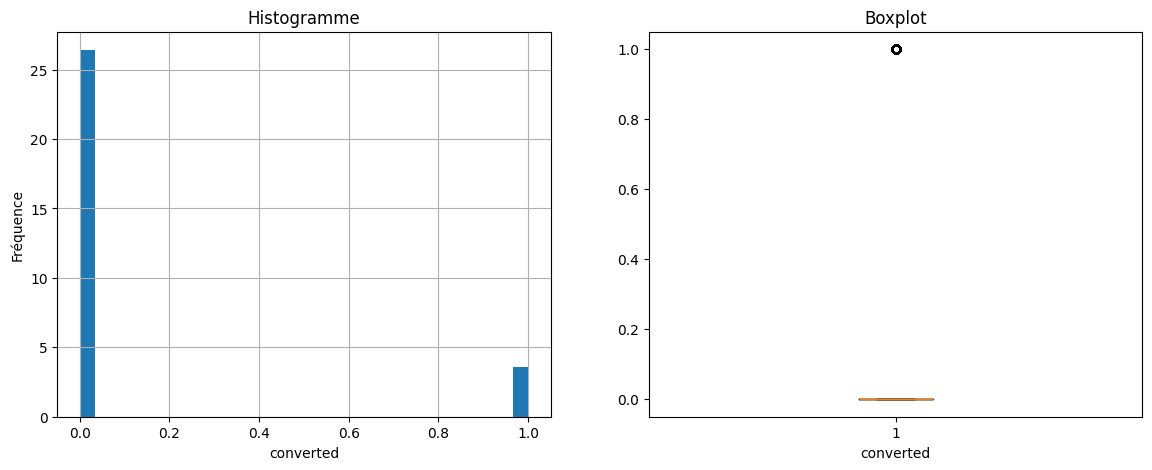

In [ ]:
dis_var = df['converted']
dis_var
figure, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(dis_var, bins=30, density=True)
ax[0].set_title('Histogramme')
ax[0].set_xlabel('converted')
ax[0].set_ylabel('Fréquence')
ax[0].grid()
ax[1].boxplot(dis_var)
ax[1].set_title('Boxplot')
ax[1].set_xlabel('converted')
figure.savefig('images/distribution_converted.png')

#### Détection des outliers

In [ ]:
def detec_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    borne_infer = Q1 - (1.5 * IQR)
    borne_super = Q3 + (1.5 * IQR)

    return data[(data[column] < borne_infer) | (data[column] > borne_super)]

outliers = detec_outliers(df, 'converted')
print('Outliers détectés')
print(outliers)

Outliers détectés
        user_id                   timestamp      group landing_page  converted
4        864975  2017-01-21 01:52:26.210827    control     old_page          1
6        679687  2017-01-19 03:26:46.940749  treatment     new_page          1
8        817355  2017-01-04 17:58:08.979471  treatment     new_page          1
9        839785  2017-01-15 18:11:06.610965  treatment     new_page          1
15       644214  2017-01-22 02:05:21.719434    control     old_page          1
...         ...                         ...        ...          ...        ...
294396   838593  2017-01-15 09:56:31.455023  treatment     new_page          1
294405   712217  2017-01-11 10:34:30.176801    control     old_page          1
294420   795742  2017-01-09 01:06:58.299207    control     old_page          1
294430   733871  2017-01-21 17:54:08.810964  treatment     new_page          1
294443   665217  2017-01-10 23:29:01.767720    control     old_page          1

[35237 rows x 5 columns]


In [ ]:
from sklearn.ensemble import IsolationForest

X_iso = df.select_dtypes(include=[np.number]).copy()

if 'Outlier' in X_iso.columns:
    X_iso = X_iso.drop(columns=['Outlier'])

iso_forest = IsolationForest(contamination=0.001, random_state=42)
outlier_labels = iso_forest.fit_predict(X_iso)

df['Outlier'] = outlier_labels
outliers = df[df['Outlier'] == -1]

print('Outliers détectés (Isolation Forest)')
n_outliers_iso = (outlier_labels == -1).sum()
print(f"Outliers détectés : {n_outliers_iso} ({n_outliers_iso/len(df)*100:.2f}%)")
print(f"Colonnes utilisées : {X_iso.shape[1]}")

Outliers détectés (Isolation Forest)
Outliers détectés : 248 (0.08%)
Colonnes utilisées : 2


Dans ce cas, la variable de conversion est binaire. La détection des outliers est donc moins critique que sur une variable continue, mais on garde les observations pour ne pas réduire inutilement la taille de l'échantillon.

#### Taux de conversion - Visualisation 

- control → Groupe A → bouton orange
- treatment → Groupe B → bouton vert

In [ ]:
taux_control = df[df['group'] == 'control']['converted'].mean()
taux_treatment = df[df['group'] == 'treatment']['converted'].mean()

print(f"Bouton orange : {taux_control:.2%}")
print(f"Bouton vert : {taux_treatment:.2%}")

Bouton orange : 12.04%
Bouton vert : 11.89%


Répartition groupes :
group
treatment    147276
control      147202
Name: count, dtype: int64

Répartition conversions :
converted
0    259241
1     35237
Name: count, dtype: int64


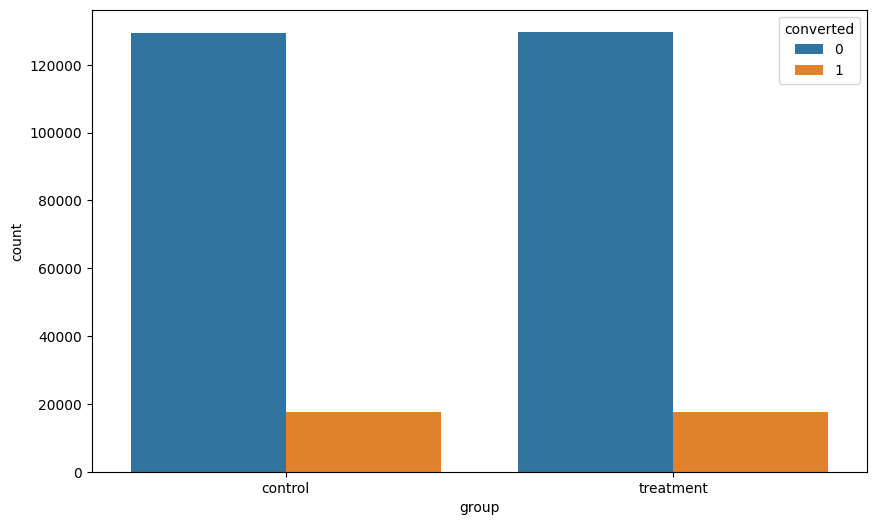

In [ ]:
print("Répartition groupes :")
print(df['group'].value_counts())

print("\nRépartition conversions :")
print(df['converted'].value_counts())

sns.countplot(x='group', hue='converted', data=df)

# Sanity Check - Vérification de l'équilibre des groupes

#### Asignation groupe/page

In [ ]:
control = df[df['group'] == 'control']['landing_page'].value_counts()
treatment = df[df['group'] == 'treatment']['landing_page'].value_counts()

print("Groupe CONTROL doit voir seulement 'old_page' :")
print(control)
print("\nGroupe TREATMENT doit voir seulement 'new_page' :")
print(treatment)

landing_page
old_page    145274
new_page      1928
Name: count, dtype: int64
landing_page
new_page    145311
old_page      1965
Name: count, dtype: int64


Le contrôle qualité révèle un problème d'assignation : certains utilisateurs du groupe control ont vu la nouvelle page, et certains utilisateurs du groupe treatment ont vu l'ancienne page. Le nettoyage est nécessaire avant toute interprétation statistique.

In [ ]:
df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]

print(f"Avant nettoyage : {len(df)} observations")
print(f"Après nettoyage : {len(df_clean)} observations")
print(f"Lignes supprimées : {len(df) - len(df_clean)} (mal assignées)")

Avant nettoyage : 294478
Après nettoyage : 290585
Lignes supprimées : 3893


#### Vérification des doublons 

Le dataset ne contient pas de doublons détectables après vérification. Cette absence de répétitions renforce la fiabilité des calculs réalisés sur les groupes.

#### Vérification -Groupes équilibrés 

In [ ]:
df['group'].value_counts(normalize=True)

group
treatment    0.500126
control      0.499874
Name: proportion, dtype: float64

# Solution Statistique 

#### Vérification de la normalité 

Avec plus de 294 000 observations, on peut s'appuyer sur le théorème central limite pour approximer la distribution de l'estimateur de conversion par une loi normale. Cela justifie l'utilisation d'un test de comparaison de proportions.

#### Vérification de l'égalité des variances 



In [ ]:
from scipy import stats

result = stats.levene(
    df[df['group'] == 'control']['converted'],
    df[df['group'] == 'treatment']['converted']
)

print(f"Statistique de test : {result.statistic:.4f}")
print(f"P-value : {result.pvalue:.4f}")

if result.pvalue > 0.05:
    print("→ Les variances sont ÉGALES (p > 0.05)")
else:
    print("→ Les variances sont DIFFÉRENTES (p < 0.05)")

LeveneResult(statistic=np.float64(1.5299729852804425), pvalue=np.float64(0.21611748562490823))

La p-value est supérieure à 0.05, ce qui indique que l'hypothèse d'égalité des variances n'est pas rejetée. On considère donc les variances comme suffisamment proches pour poursuivre l'analyse.

#### Choix du test statistique

Même si le t-test pourrait convenir en théorie, la taille très importante de l'échantillon rend le Z-test de proportions plus adapté pour comparer les taux de conversion entre les deux groupes.

#### Les hypothèses


- H0 : il n'y a pas de différence entre les taux de conversion des deux groupes.
- H1 : les taux de conversion sont différents.
- On fixe un seuil de signification de 5 % : si la p-value est inférieure à 0.05, on rejette H0.
- L'objectif est de vérifier si la nouvelle variante améliore réellement la conversion ou si l'écart observé est dû au hasard.

#### Calcul de la p-value et conclusion business 

#### Test statistique : Z-test bilatéral

#### Z-TEST BILATÉRAL (TEST A/B)
========================================
Test pour comparer 2 proportions avec grands échantillons
Hypothèses :
- H0 : p_control = p_treatment (pas de différence)
- H1 : p_control ≠ p_treatment (différence existe)
- α = 0.05 (seuil de signification)

On utilise ici un Z-test bilatéral pour comparer les taux de conversion des deux groupes après nettoyage des données.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

conversions_control = df_clean[df_clean['group'] == 'control']['converted'].sum()
n_control = len(df_clean[df_clean['group'] == 'control'])
taux_control = conversions_control / n_control

conversions_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].sum()
n_treatment = len(df_clean[df_clean['group'] == 'treatment'])
taux_treatment = conversions_treatment / n_treatment

print(f"Taux Control (bouton orange)   : {taux_control:.4f} ({taux_control:.2%})")
print(f"Taux Treatment (bouton vert)   : {taux_treatment:.4f} ({taux_treatment:.2%})")
print(f"Différence absolue             : {abs(taux_treatment - taux_control):.4f}")
print(f"Lift (gain relatif)            : {((taux_treatment - taux_control) / taux_control):.2%}")

stat, p_value = proportions_ztest(
    count=[conversions_control, conversions_treatment],
    nobs=[n_control, n_treatment],
    alternative='two-sided'
)

print(f"\nZ-statistique : {stat:.4f}")
print(f"P-value       : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n P-value ({p_value:.4f}) < α ({alpha})")
    print("→ On REJETTE H0")
    print("→ Il existe une différence significative entre les deux boutons")
    if taux_treatment > taux_control:
        print("→ Le bouton VERT convertit mieux")
    else:
        print("→ Le bouton ORANGE convertit mieux")
else:
    print(f"\n P-value ({p_value:.4f}) > α ({alpha})")
    print("→ On NE REJETTE PAS H0")
    print("→ Pas de différence significative — garder l'ancien bouton (orange)")

Taux Control (bouton orange)   : 0.1204 (12.04%)
Taux Treatment (bouton vert)   : 0.1188 (11.88%)
Différence absolue             : 0.0016
Lift                           : -1.31%

Z-statistique : 1.3116
P-value       : 0.1897

 P-value (0.1897) > α (0.05)
→ On NE REJETTE PAS H0
→ Pas de différence significative — garder l'ancien bouton (orange)


# Réponses aux questions business 

In [ ]:
diff = taux_treatment - taux_control
lift = diff / taux_control

print("=" * 60)
print("SYNTHÈSE DE L'A/B TEST")
print("=" * 60)

print(f"\n1. Taux de conversion par groupe :")
print(f"   - Groupe A (Control, bouton orange) : {taux_control:.4f} ({taux_control:.2%})")
print(f"   - Groupe B (Treatment, bouton vert) : {taux_treatment:.4f} ({taux_treatment:.2%})")

print(f"\n2. Différence et impact :")
print(f"   - Difference absolue (B - A)        : {diff:.4f} ({diff:.2%})")
print(f"   - Lift relatif                      : {lift:.2%}")

print(f"\n3. Significativité statistique :")
print(f"   - P-value                           : {p_value:.6f}")
print(f"   - Significatif au seuil 5% ?        : {'OUI ✓' if p_value < 0.05 else 'NON ✗'}")

print(f"\n4. Recommandation business :")
if p_value < 0.05:
    if taux_treatment > taux_control:
        print("   → DÉPLOYER le bouton vert (meilleure conversion)")
    else:
        print("   → GARDER le bouton orange (conversion plus élevée)")
else:
    print("   → GARDER le bouton orange (pas d'amélioration)\n")
    print("   Note : La différence observée peut être due au hasard\n")
    print("   Actions possibles :")
    print("   - Prolonger le test pour augmenter la puissance")
    print("   - Améliorer le design du bouton vert")
    print("   - Tester d'autres variantes")

print("\n" + "=" * 60)

Taux de conversion Groupe A (control): 0.1204 (12.04%)
Taux de conversion Groupe B (treatment): 0.1188 (11.88%)
Difference absolue (B - A): -0.0016 (-0.16%)
Lift relatif: -1.31%
p-value: 0.189653
Significatif au seuil 5%: False


La synthèse finale montre que le bouton vert ne surperforme pas de manière significative le bouton orange. L'écart observé reste faible et peut être attribué au hasard d'échantillonnage, ce qui conduit à recommander le maintien de la version actuelle.